---
Phase 4-NLP-1: 詞嵌入 — 讓電腦「理解」文字
---

電腦只懂數字，那文字怎麼辦？
  → 把每個字/詞變成一個向量！

演進：
  One-Hot → 共現矩陣/SVD → Word2Vec → 最終到 Transformer

本檔涵蓋：
  1. One-Hot Encoding — 最簡單但最差
  2. 共現矩陣 + SVD — 基於統計
  3. Word2Vec (Skip-gram) — 從零實作
  4. nn.Embedding — PyTorch 的用法
  5. 詞向量的有趣性質

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================================
# 1. One-Hot Encoding
# ============================================================================

In [2]:
print("=" * 60)
print("1. One-Hot Encoding — 最直覺的表示法")
print("=" * 60)

print("""
假設詞彙表有 5 個字：['我', '愛', '貓', '狗', '你']

One-Hot 表示：
  我 → [1, 0, 0, 0, 0]
  愛 → [0, 1, 0, 0, 0]
  貓 → [0, 0, 1, 0, 0]
  狗 → [0, 0, 0, 1, 0]
  你 → [0, 0, 0, 0, 1]

問題：
  1. 維度 = 詞彙量（可能 50,000+）→ 太高維
  2. 所有向量正交 → 「貓」和「狗」的距離 = 「貓」和「愛」的距離
     → 完全沒有語義資訊！
  3. 稀疏（幾乎全是 0）→ 浪費空間
""")

# 實作
vocab = ['我', '愛', '貓', '狗', '你', '他', '吃', '魚']
word2idx = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)

# One-Hot
def one_hot(word, word2idx, vocab_size):
    vec = np.zeros(vocab_size)
    vec[word2idx[word]] = 1
    return vec

for word in ['貓', '狗', '魚']:
    print(f"  {word}: {one_hot(word, word2idx, vocab_size)}")

# 計算距離
cat = one_hot('貓', word2idx, vocab_size)
dog = one_hot('狗', word2idx, vocab_size)
fish = one_hot('魚', word2idx, vocab_size)
love = one_hot('愛', word2idx, vocab_size)

print(f"\n  貓-狗 距離: {np.linalg.norm(cat - dog):.4f}")
print(f"  貓-魚 距離: {np.linalg.norm(cat - fish):.4f}")
print(f"  貓-愛 距離: {np.linalg.norm(cat - love):.4f}")
print(f"  → 所有距離都一樣！One-Hot 沒有語義。")

1. One-Hot Encoding — 最直覺的表示法

假設詞彙表有 5 個字：['我', '愛', '貓', '狗', '你']

One-Hot 表示：
  我 → [1, 0, 0, 0, 0]
  愛 → [0, 1, 0, 0, 0]
  貓 → [0, 0, 1, 0, 0]
  狗 → [0, 0, 0, 1, 0]
  你 → [0, 0, 0, 0, 1]

問題：
  1. 維度 = 詞彙量（可能 50,000+）→ 太高維
  2. 所有向量正交 → 「貓」和「狗」的距離 = 「貓」和「愛」的距離
     → 完全沒有語義資訊！
  3. 稀疏（幾乎全是 0）→ 浪費空間

  貓: [0. 0. 1. 0. 0. 0. 0. 0.]
  狗: [0. 0. 0. 1. 0. 0. 0. 0.]
  魚: [0. 0. 0. 0. 0. 0. 0. 1.]

  貓-狗 距離: 1.4142
  貓-魚 距離: 1.4142
  貓-愛 距離: 1.4142
  → 所有距離都一樣！One-Hot 沒有語義。


## 2. 共現矩陣 + SVD — 基於統計的方法


2. 共現矩陣 — 靠上下文定義語義

語言學假說：「你可以從一個詞的鄰居知道它的意思」(Distributional Hypothesis)

  "The cat sat on the mat"
  "The dog sat on the rug"
  → cat 和 dog 的上下文很像 → 語義接近

做法：統計哪些詞常常一起出現（共現矩陣）
  然後用 SVD 降維 → 得到低維的詞向量

詞彙表 (15 個字): ['a', 'big', 'cat', 'chased', 'dog', 'fish', 'is', 'likes', 'mat', 'meat', 'on', 'rug', 'sat', 'small', 'the']

共現矩陣 (部分):
         cat   dog  fish   sat   the
   cat     0     0     1     1     5
   dog     0     0     0     1     5
  fish     1     0     0     0     0
   sat     1     1     0     0     4
   the     5     5     0     4     0

SVD 降維到 2D:
     cat: [-4.698, +3.240]
     dog: [-4.698, +3.240]
    fish: [-0.474, -0.328]
     sat: [-3.696, +2.164]
     the: [-7.405, -6.044]


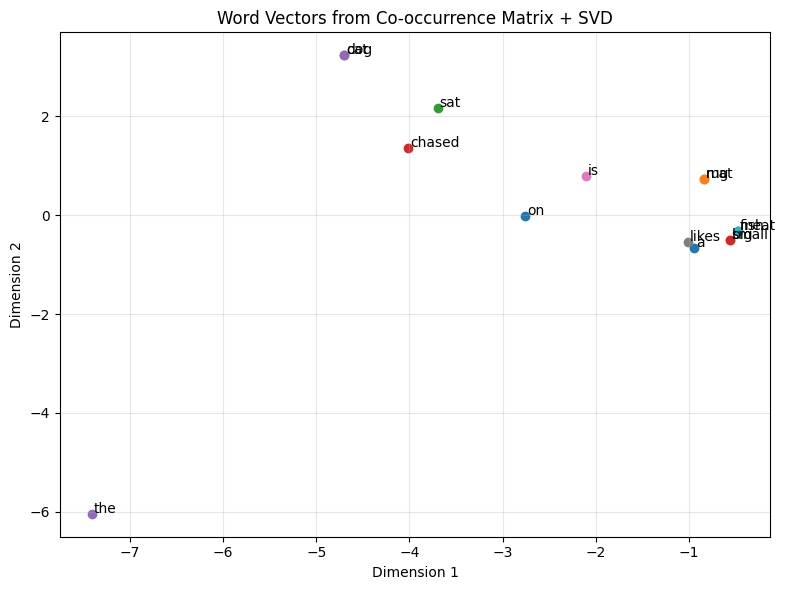


→ 圖表儲存至 nlp/plots/01_svd_embeddings.png
  → cat 和 dog 應該在附近（相似的上下文）


In [3]:
print("\n" + "=" * 60)
print("2. 共現矩陣 — 靠上下文定義語義")
print("=" * 60)

print("""
語言學假說：「你可以從一個詞的鄰居知道它的意思」(Distributional Hypothesis)

  "The cat sat on the mat"
  "The dog sat on the rug"
  → cat 和 dog 的上下文很像 → 語義接近

做法：統計哪些詞常常一起出現（共現矩陣）
  然後用 SVD 降維 → 得到低維的詞向量
""")

# 建立小型語料庫
corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat chased the dog",
    "the dog chased the cat",
    "a cat likes fish",
    "a dog likes meat",
    "the cat is small",
    "the dog is big",
]

# 建立詞彙表
all_words = []
for sent in corpus:
    all_words.extend(sent.split())
word_counts = Counter(all_words)
en_vocab = sorted(set(all_words))
en_word2idx = {w: i for i, w in enumerate(en_vocab)}
en_vocab_size = len(en_vocab)
print(f"詞彙表 ({en_vocab_size} 個字): {en_vocab}")

# 建立共現矩陣
window_size = 2
cooccurrence = np.zeros((en_vocab_size, en_vocab_size))

for sent in corpus:
    words = sent.split()
    for i, word in enumerate(words):
        for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
            if i != j:
                cooccurrence[en_word2idx[word], en_word2idx[words[j]]] += 1

print(f"\n共現矩陣 (部分):")
show_words = ['cat', 'dog', 'fish', 'sat', 'the']
show_idx = [en_word2idx[w] for w in show_words]
print(f"{'':>6s}", end='')
for w in show_words:
    print(f"{w:>6s}", end='')
print()
for w, i in zip(show_words, show_idx):
    print(f"{w:>6s}", end='')
    for j in show_idx:
        print(f"{cooccurrence[i, j]:6.0f}", end='')
    print()

# SVD 降維
from numpy.linalg import svd

U, S, Vt = svd(cooccurrence, full_matrices=False)
# 取前 2 維
embedding_dim = 2
word_vectors = U[:, :embedding_dim] * S[:embedding_dim]

print(f"\nSVD 降維到 {embedding_dim}D:")
for w in ['cat', 'dog', 'fish', 'sat', 'the']:
    vec = word_vectors[en_word2idx[w]]
    print(f"  {w:>6s}: [{vec[0]:+.3f}, {vec[1]:+.3f}]")

# 視覺化
fig, ax = plt.subplots(figsize=(8, 6))
for w in en_vocab:
    idx = en_word2idx[w]
    ax.scatter(word_vectors[idx, 0], word_vectors[idx, 1])
    ax.annotate(w, (word_vectors[idx, 0] + 0.02, word_vectors[idx, 1] + 0.02), fontsize=10)

ax.set_title('Word Vectors from Co-occurrence Matrix + SVD')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-4-domains/nlp/plots/01_svd_embeddings.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 nlp/plots/01_svd_embeddings.png")
print("  → cat 和 dog 應該在附近（相似的上下文）")

## 3. Word2Vec (Skip-gram) — 從零實作

In [4]:
print("\n" + "=" * 60)
print("3. Word2Vec — 神經網路學詞向量")
print("=" * 60)

print("""
Word2Vec 的核心想法：
  用一個詞預測它的上下文（Skip-gram）
  或用上下文預測中間的詞（CBOW）

Skip-gram:
  輸入: "cat"
  目標: 預測 "the", "sat"（周圍的詞）

  模型結構超簡單：
    word → Embedding(vocab_size, embed_dim) → Linear(embed_dim, vocab_size)

    Embedding 層的權重 = 學到的詞向量！

  為什麼有效？
  因為相似上下文的詞，會被推到 embedding 空間的附近位置。
""")


class SkipGram(nn.Module):
    """簡單的 Skip-gram Word2Vec"""
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, center_word):
        embed = self.embedding(center_word)    # (batch, embed_dim)
        logits = self.output(embed)             # (batch, vocab_size)
        return logits


# 準備訓練資料
def make_skipgram_data(corpus, word2idx, window=2):
    """建立 (center, context) pairs"""
    pairs = []
    for sent in corpus:
        words = sent.split()
        for i, word in enumerate(words):
            for j in range(max(0, i - window), min(len(words), i + window + 1)):
                if i != j:
                    pairs.append((word2idx[word], word2idx[words[j]]))
    return pairs

pairs = make_skipgram_data(corpus, en_word2idx, window=2)
print(f"訓練對數: {len(pairs)}")
print(f"範例: {[(en_vocab[c], en_vocab[t]) for c, t in pairs[:5]]}")

# 訓練
embed_dim = 8
model = SkipGram(en_vocab_size, embed_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

centers = torch.tensor([p[0] for p in pairs])
targets = torch.tensor([p[1] for p in pairs])

print(f"\n訓練 Word2Vec (embed_dim={embed_dim})...")
for epoch in range(200):
    logits = model(centers)
    loss = criterion(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}: Loss = {loss.item():.4f}")

# 取出學到的詞向量
learned_vectors = model.embedding.weight.detach().numpy()
print(f"\n學到的詞向量 shape: {learned_vectors.shape}")

# 計算詞之間的相似度（cosine similarity）
def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("\n詞相似度（cosine similarity）:")
word_pairs = [('cat', 'dog'), ('cat', 'fish'), ('sat', 'chased'),
              ('the', 'a'), ('cat', 'the')]
for w1, w2 in word_pairs:
    v1 = learned_vectors[en_word2idx[w1]]
    v2 = learned_vectors[en_word2idx[w2]]
    sim = cosine_sim(v1, v2)
    print(f"  {w1:>8s} - {w2:<8s}: {sim:+.3f}")


3. Word2Vec — 神經網路學詞向量

Word2Vec 的核心想法：
  用一個詞預測它的上下文（Skip-gram）
  或用上下文預測中間的詞（CBOW）

Skip-gram:
  輸入: "cat"
  目標: 預測 "the", "sat"（周圍的詞）

  模型結構超簡單：
    word → Embedding(vocab_size, embed_dim) → Linear(embed_dim, vocab_size)

    Embedding 層的權重 = 學到的詞向量！

  為什麼有效？
  因為相似上下文的詞，會被推到 embedding 空間的附近位置。

訓練對數: 104
範例: [('the', 'cat'), ('the', 'sat'), ('cat', 'the'), ('cat', 'sat'), ('cat', 'on')]



訓練 Word2Vec (embed_dim=8)...
  Epoch   0: Loss = 2.9372
  Epoch  50: Loss = 1.9562


  Epoch 100: Loss = 1.6980
  Epoch 150: Loss = 1.6222

學到的詞向量 shape: (15, 8)

詞相似度（cosine similarity）:
       cat - dog     : +0.238
       cat - fish    : -0.088
       sat - chased  : +0.441
       the - a       : +0.157
       cat - the     : +0.343


## 4. nn.Embedding — PyTorch 的標準用法

In [5]:
print("\n" + "=" * 60)
print("4. nn.Embedding — 查表取向量")
print("=" * 60)

print("""
nn.Embedding 本質上就是一個查找表（lookup table）：
  - 輸入: 整數索引 [3, 1, 4]
  - 輸出: 對應的向量 [embed[3], embed[1], embed[4]]

等價於 one-hot × weight matrix:
  one_hot([3]) × W = W[3]

但 nn.Embedding 更高效（不用做矩陣乘法，直接查表）。
""")

# 建立 Embedding
embed = nn.Embedding(num_embeddings=100, embedding_dim=16)

print(f"Embedding 權重 shape: {embed.weight.shape}")  # (100, 16)

# 輸入索引
indices = torch.tensor([0, 5, 3, 7])
vectors = embed(indices)
print(f"輸入: {indices}")
print(f"輸出 shape: {vectors.shape}")  # (4, 16)
print(f"第一個向量: {vectors[0][:5]}...")  # 前 5 維

# 在句子中使用
print("\n--- 在句子中使用 ---")
sentence = "the cat sat on the mat"
words = sentence.split()
word_indices = torch.tensor([en_word2idx[w] for w in words])
print(f"句子: {sentence}")
print(f"索引: {word_indices}")

sent_embed = nn.Embedding(en_vocab_size, 8)
word_vectors_out = sent_embed(word_indices)
print(f"詞向量 shape: {word_vectors_out.shape}")  # (6, 8)
print(f"→ 每個詞變成一個 8 維向量")

# Padding（不同長度的句子）
print("\n--- Padding ---")
print("""
不同長度的句子需要 padding 到同一長度：
  "the cat"     → [1, 2, 0, 0]    (pad with 0)
  "the dog sat" → [1, 3, 4, 0]

padding_idx 讓 index=0 的向量永遠是零向量：
  embed = nn.Embedding(100, 16, padding_idx=0)
""")

embed_with_pad = nn.Embedding(100, 8, padding_idx=0)
padded = torch.tensor([[1, 2, 3, 0], [4, 5, 0, 0]])
out = embed_with_pad(padded)
print(f"Padded input: {padded}")
print(f"Index 0 的向量全是 0: {out[0, 3]}")  # 應該全是 0


4. nn.Embedding — 查表取向量

nn.Embedding 本質上就是一個查找表（lookup table）：
  - 輸入: 整數索引 [3, 1, 4]
  - 輸出: 對應的向量 [embed[3], embed[1], embed[4]]

等價於 one-hot × weight matrix:
  one_hot([3]) × W = W[3]

但 nn.Embedding 更高效（不用做矩陣乘法，直接查表）。

Embedding 權重 shape: torch.Size([100, 16])
輸入: tensor([0, 5, 3, 7])
輸出 shape: torch.Size([4, 16])
第一個向量: tensor([ 0.8654, -0.2417, -0.6690, -1.0646,  0.6565], grad_fn=<SliceBackward0>)...

--- 在句子中使用 ---
句子: the cat sat on the mat
索引: tensor([14,  2, 12, 10, 14,  8])
詞向量 shape: torch.Size([6, 8])
→ 每個詞變成一個 8 維向量

--- Padding ---

不同長度的句子需要 padding 到同一長度：
  "the cat"     → [1, 2, 0, 0]    (pad with 0)
  "the dog sat" → [1, 3, 4, 0]

padding_idx 讓 index=0 的向量永遠是零向量：
  embed = nn.Embedding(100, 16, padding_idx=0)

Padded input: tensor([[1, 2, 3, 0],
        [4, 5, 0, 0]])
Index 0 的向量全是 0: tensor([0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)


## 5. 詞向量的有趣性質


5. 詞向量的有趣性質

經典發現（在大語料上訓練的 Word2Vec/GloVe）：

  king - man + woman ≈ queen
  Paris - France + Japan ≈ Tokyo
  bigger - big + small ≈ smaller

向量運算 = 語義運算！

  vec("king") - vec("man") ≈ "皇室" 的概念
  加上 vec("woman") ≈ "女性皇室" = queen

  這裡我們的語料太小，無法看到這個效果，
  但可以理解原理。



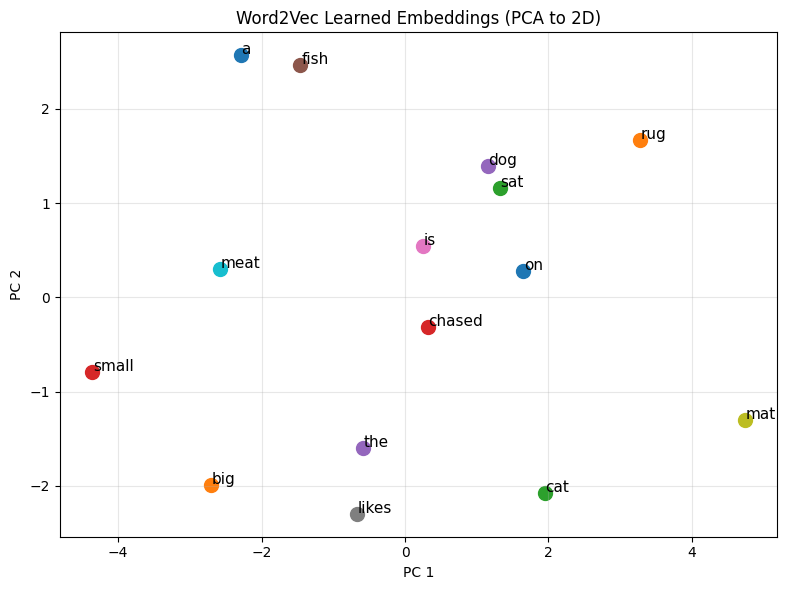

→ 圖表儲存至 nlp/plots/01_word2vec_embeddings.png


In [6]:
print("\n" + "=" * 60)
print("5. 詞向量的有趣性質")
print("=" * 60)

print("""
經典發現（在大語料上訓練的 Word2Vec/GloVe）：

  king - man + woman ≈ queen
  Paris - France + Japan ≈ Tokyo
  bigger - big + small ≈ smaller

向量運算 = 語義運算！

  vec("king") - vec("man") ≈ "皇室" 的概念
  加上 vec("woman") ≈ "女性皇室" = queen

  這裡我們的語料太小，無法看到這個效果，
  但可以理解原理。
""")

# 用 PCA 降維到 2D 視覺化學到的向量
from numpy.linalg import svd as np_svd

# PCA
mean_vec = learned_vectors.mean(axis=0)
centered = learned_vectors - mean_vec
U_pca, S_pca, Vt_pca = np_svd(centered, full_matrices=False)
vectors_2d = centered @ Vt_pca[:2].T

fig, ax = plt.subplots(figsize=(8, 6))
for i, w in enumerate(en_vocab):
    ax.scatter(vectors_2d[i, 0], vectors_2d[i, 1], s=100)
    ax.annotate(w, (vectors_2d[i, 0] + 0.01, vectors_2d[i, 1] + 0.01), fontsize=11)

ax.set_title('Word2Vec Learned Embeddings (PCA to 2D)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-4-domains/nlp/plots/01_word2vec_embeddings.png', dpi=100)
plt.show()
print("→ 圖表儲存至 nlp/plots/01_word2vec_embeddings.png")

## 小結

In [7]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
詞嵌入的演進：

  方法              維度       語義     訓練方式
  ─────────────────────────────────────────────────
  One-Hot          vocab_size  無      不需要
  共現矩陣+SVD     自定        有      統計 + SVD
  Word2Vec         自定        有      神經網路（淺層）
  GloVe            自定        有      統計 + 神經網路
  FastText         自定        有      子詞級 Word2Vec

  現代做法：
  - 不再用固定的詞向量
  - Transformer 的 Embedding 是「上下文相關」的
  - 同一個詞在不同句子中有不同的向量！
  - 但理解 Word2Vec 是理解 Transformer 的基礎

  關鍵概念：
  1. Embedding = 查找表（整數 → 向量）
  2. 相似的詞 → 相似的向量
  3. 向量運算 ≈ 語義運算
  4. Embedding 是可學習的參數

下一步：02_rnn_lstm.py — 序列模型
""")


小結

詞嵌入的演進：

  方法              維度       語義     訓練方式
  ─────────────────────────────────────────────────
  One-Hot          vocab_size  無      不需要
  共現矩陣+SVD     自定        有      統計 + SVD
  Word2Vec         自定        有      神經網路（淺層）
  GloVe            自定        有      統計 + 神經網路
  FastText         自定        有      子詞級 Word2Vec

  現代做法：
  - 不再用固定的詞向量
  - Transformer 的 Embedding 是「上下文相關」的
  - 同一個詞在不同句子中有不同的向量！
  - 但理解 Word2Vec 是理解 Transformer 的基礎

  關鍵概念：
  1. Embedding = 查找表（整數 → 向量）
  2. 相似的詞 → 相似的向量
  3. 向量運算 ≈ 語義運算
  4. Embedding 是可學習的參數

下一步：02_rnn_lstm.py — 序列模型

